DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:aido_schemas:aido-protocols version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:nodes:version 6.2.17 path /usr/local/lib/python3.8/dist-packages pyparsing 2.4.6
DEBUG:dt_protocols:dt-protocols version 6.2.35 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_world:duckietown-world version 6.4.3 path /usr/local/lib/python3.8/dist-packages
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_challenges:duckietown_challenges version 6.5.2 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_build_utils:duckietown_build_utils version 6.2.78 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_docker_utils:duckietown_docker_utils version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:ipce:version 6.1.2 path /usr/local/lib/python3.8/dist-packages


PlanStep
│ duration: 11.780972450961723
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: 7.639437268410977
90.0
[FriendlyPose(x=1.08, y=1.0, theta_deg=2), FriendlyPose(x=1.28, y=1.01, theta_deg=5), FriendlyPose(x=1.48, y=1.04, theta_deg=9), FriendlyPose(x=1.67, y=1.08, theta_deg=13), FriendlyPose(x=1.87, y=1.13, theta_deg=17), FriendlyPose(x=2.06, y=1.19, theta_deg=21), FriendlyPose(x=2.24, y=1.27, theta_deg=24), FriendlyPose(x=2.42, y=1.36, theta_deg=28), FriendlyPose(x=2.59, y=1.46, theta_deg=32), FriendlyPose(x=2.76, y=1.57, theta_deg=36), FriendlyPose(x=2.92, y=1.69, theta_deg=40), FriendlyPose(x=3.07, y=1.83, theta_deg=44), FriendlyPose(x=3.21, y=1.97, theta_deg=47), FriendlyPose(x=3.34, y=2.12, theta_deg=51), FriendlyPose(x=3.46, y=2.28, theta_deg=55), FriendlyPose(x=3.57, y=2.45, theta_deg=59), FriendlyPose(x=3.66, y=2.62, theta_deg=63), FriendlyPose(x=3.75, y=2.8, theta_deg=66), FriendlyPose(x=3.82, y=2.99, theta_deg=70), FriendlyPose(x=3.89, y=3.18, theta_deg=74), FriendlyPose(

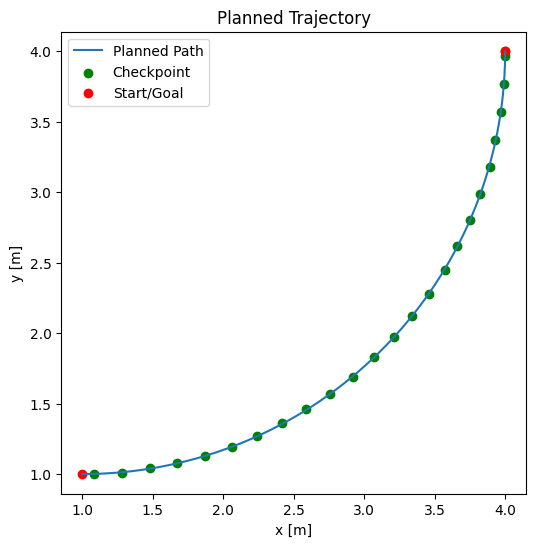

In [1]:
from planning.planner import connect_poses_with_curvature, plan_to_destination, pose_to_node, node_to_pose, plan_to_destination_dt
import matplotlib.pyplot as plt
from aido_schemas import Context, FriendlyPose
from dt_protocols import PlanningSetup, Rectangle, Circle, PlacedPrimitive
import math
import numpy as np

ps = PlanningSetup(
    bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=3.0, ymax=3.0),
    max_linear_velocity_m_s=0.4,
    min_linear_velocity_m_s=-0.3,
    max_angular_velocity_deg_s=30.0,
    max_curvature=math.inf,
    tolerance_xy_m=0.05,
    tolerance_theta_deg=20.0,
    environment=[],
    body=[]
)

start = FriendlyPose(x=1, y=1, theta_deg=0.0)
goal = FriendlyPose(x=4, y=4, theta_deg=45.0)

def simulate_plan(start_pose, plan):
    """
    Simulate the trajectory given a start pose and a plan (list of PlanStep).
    Returns arrays of x, y, theta.
    """
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg
    xs, ys, thetas = [x], [y], [theta_deg]
    for step in plan:
        duration = step.duration
        v = step.velocity_x_m_s
        w_deg = step.angular_velocity_deg_s
        w = np.deg2rad(w_deg)
        theta = np.deg2rad(theta_deg)
        # Simulate in small increments for smoothness
        dt = 0.001
        n = int(duration / dt)
        for _ in range(n):
            if abs(w) < 1e-6:
                # Straight line
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
            else:
                # Arc
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
                theta += w * dt
            xs.append(x)
            ys.append(y)
            thetas.append(np.rad2deg(theta))
        theta_deg = np.rad2deg(theta)
    return np.array(xs), np.array(ys), np.array(thetas)

def simulate_and_plot(ps, start, goal):
    # Simulate and plot
    plan, new_heading = connect_poses_with_curvature(ps, start, goal)
    print(plan)
    print(new_heading)

    xs, ys, thetas = simulate_plan(start, [plan])
    dest = plan_to_destination_dt(plan, pose_to_node(start), 0.5, 0.2)
    dest = list(map(node_to_pose, dest))
    dest_x = [p.x for p in dest]
    dest_y = [p.y for p in dest]
    print(dest)

    plt.figure(figsize=(6,6))
    plt.plot(xs, ys, label="Planned Path")
    plt.scatter(dest_x, dest_y, c='green', label="Checkpoint")
    plt.scatter([start.x, goal.x], [start.y, goal.y], c='red', label="Start/Goal")
    plt.axis('equal')
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Planned Trajectory")
    plt.legend()
    plt.show()

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 3.0
│ velocity_x_m_s: 0.2617993877991495
│ angular_velocity_deg_s: 30.0
270.0
[FriendlyPose(x=1.45, y=1.5, theta_deg=186), FriendlyPose(x=1.32, y=1.47, theta_deg=201), FriendlyPose(x=1.21, y=1.4, theta_deg=216), FriendlyPose(x=1.11, y=1.31, theta_deg=231), FriendlyPose(x=1.04, y=1.2, theta_deg=246), FriendlyPose(x=1.01, y=1.08, theta_deg=261), FriendlyPose(x=1.0, y=1.0, theta_deg=270)]


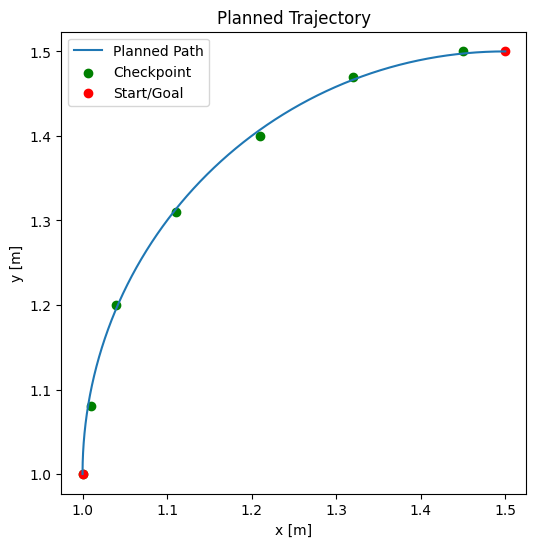

In [2]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=180)
goal = FriendlyPose(x=1, y=1, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 4.771003411805198
│ velocity_x_m_s: 0.17453292519943298
│ angular_velocity_deg_s: 30.0
323.13010235415595
[FriendlyPose(x=1.17, y=1.6, theta_deg=186), FriendlyPose(x=1.08, y=1.58, theta_deg=201), FriendlyPose(x=1.0, y=1.54, theta_deg=216), FriendlyPose(x=0.94, y=1.48, theta_deg=231), FriendlyPose(x=0.9, y=1.4, theta_deg=246), FriendlyPose(x=0.87, y=1.32, theta_deg=261), FriendlyPose(x=0.87, y=1.23, theta_deg=276), FriendlyPose(x=0.89, y=1.15, theta_deg=291), FriendlyPose(x=0.93, y=1.07, theta_deg=306), FriendlyPose(x=0.99, y=1.01, theta_deg=321), FriendlyPose(x=1.0, y=1.0, theta_deg=323)]


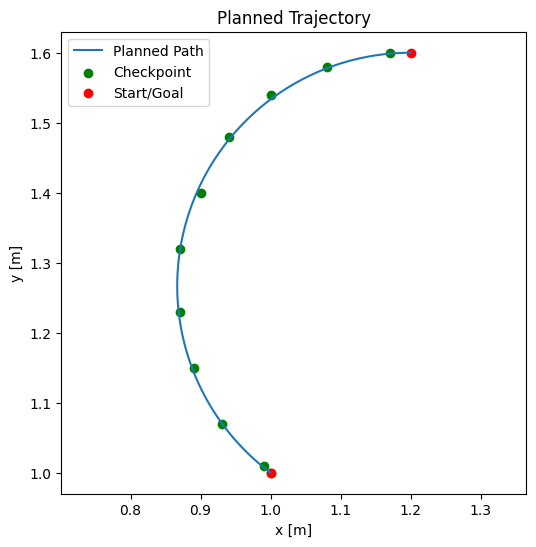

In [3]:
start = FriendlyPose(x=1.2, y=1.6, theta_deg=180)
goal = FriendlyPose(x=1, y=1, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 0.1250000000000001
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: 0.0
0
[FriendlyPose(x=1.55, y=1.5, theta_deg=0)]


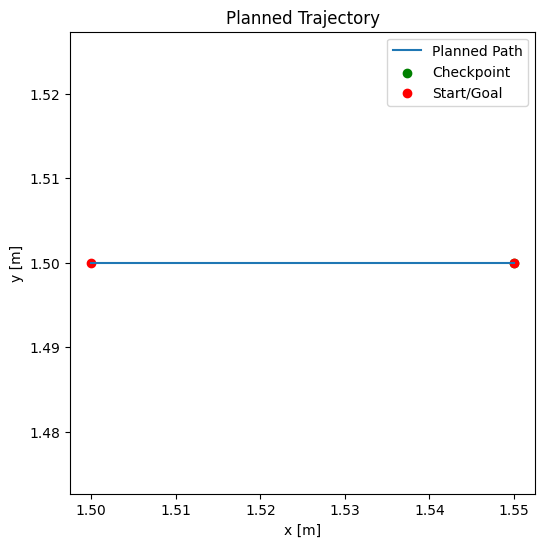

In [4]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1.55, y=1.5, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 6.0
│ velocity_x_m_s: 0.1308996938995747
│ angular_velocity_deg_s: 30.0
180.0
[FriendlyPose(x=1.53, y=1.5, theta_deg=6), FriendlyPose(x=1.59, y=1.52, theta_deg=21), FriendlyPose(x=1.65, y=1.55, theta_deg=36), FriendlyPose(x=1.69, y=1.59, theta_deg=51), FriendlyPose(x=1.73, y=1.65, theta_deg=66), FriendlyPose(x=1.75, y=1.71, theta_deg=81), FriendlyPose(x=1.75, y=1.78, theta_deg=96), FriendlyPose(x=1.73, y=1.84, theta_deg=111), FriendlyPose(x=1.7, y=1.9, theta_deg=126), FriendlyPose(x=1.66, y=1.94, theta_deg=141), FriendlyPose(x=1.6, y=1.98, theta_deg=156), FriendlyPose(x=1.54, y=2.0, theta_deg=171), FriendlyPose(x=1.5, y=2.0, theta_deg=180)]


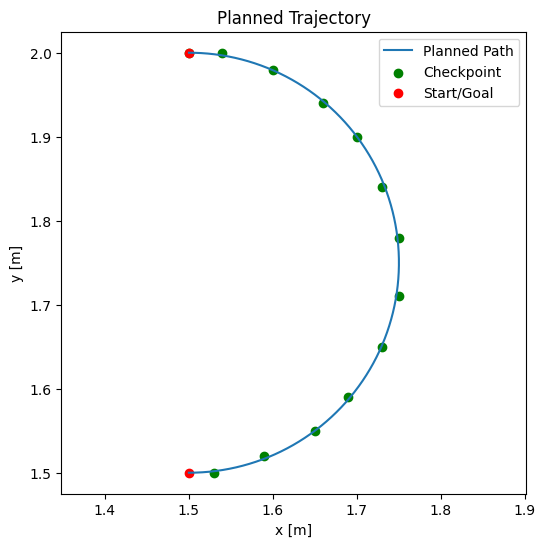

In [5]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1.5, y=2.0, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 1.6666666666666667
│ velocity_x_m_s: 0.043803152675131476
│ angular_velocity_deg_s: 30.0
70.0
[FriendlyPose(x=1.51, y=1.5, theta_deg=26), FriendlyPose(x=1.53, y=1.52, theta_deg=41), FriendlyPose(x=1.54, y=1.53, theta_deg=56), FriendlyPose(x=1.55, y=1.55, theta_deg=70)]


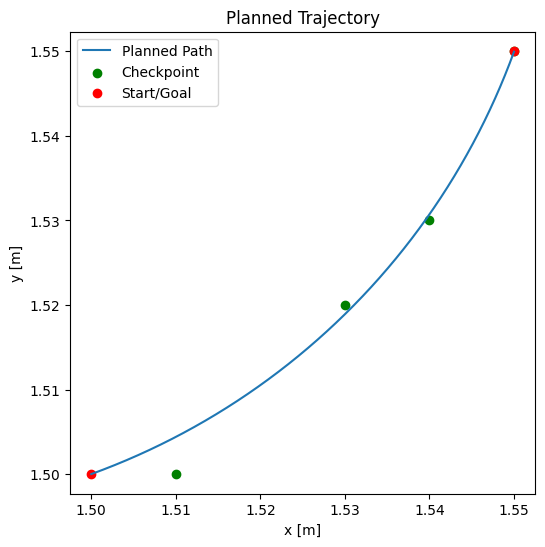

In [6]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=20.0)
goal = FriendlyPose(x=1.55, y=1.55, theta_deg=0.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 1.3333333333333333
│ velocity_x_m_s: -0.07654502020071563
│ angular_velocity_deg_s: 30.0
20.0
[FriendlyPose(x=1.49, y=1.5, theta_deg=346), FriendlyPose(x=1.45, y=1.51, theta_deg=1), FriendlyPose(x=1.41, y=1.5, theta_deg=16), FriendlyPose(x=1.4, y=1.5, theta_deg=20)]


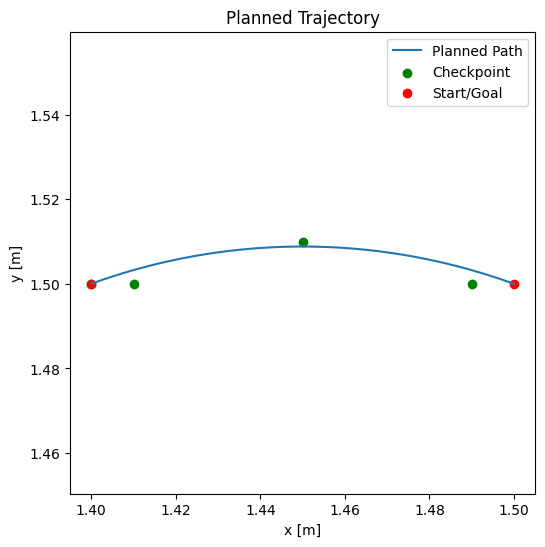

In [7]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=340)
goal = FriendlyPose(x=1.40, y=1.50, theta_deg=20.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 3.0
│ velocity_x_m_s: -0.2617993877991495
│ angular_velocity_deg_s: 30.0
90.0
[FriendlyPose(x=1.45, y=1.5, theta_deg=6), FriendlyPose(x=1.32, y=1.47, theta_deg=21), FriendlyPose(x=1.21, y=1.4, theta_deg=36), FriendlyPose(x=1.11, y=1.31, theta_deg=51), FriendlyPose(x=1.04, y=1.2, theta_deg=66), FriendlyPose(x=1.01, y=1.08, theta_deg=81), FriendlyPose(x=1.0, y=1.0, theta_deg=90)]


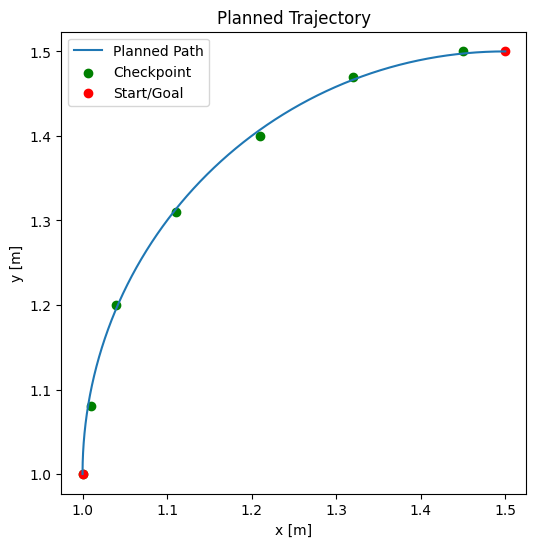

In [8]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1, y=1, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 4.771003411805199
│ velocity_x_m_s: -0.174532925199433
│ angular_velocity_deg_s: 30.0
143.13010235415598
[FriendlyPose(x=1.17, y=1.6, theta_deg=6), FriendlyPose(x=1.08, y=1.58, theta_deg=21), FriendlyPose(x=1.0, y=1.54, theta_deg=36), FriendlyPose(x=0.94, y=1.48, theta_deg=51), FriendlyPose(x=0.9, y=1.4, theta_deg=66), FriendlyPose(x=0.87, y=1.32, theta_deg=81), FriendlyPose(x=0.87, y=1.23, theta_deg=96), FriendlyPose(x=0.89, y=1.15, theta_deg=111), FriendlyPose(x=0.93, y=1.07, theta_deg=126), FriendlyPose(x=0.99, y=1.01, theta_deg=141), FriendlyPose(x=1.0, y=1.0, theta_deg=143)]


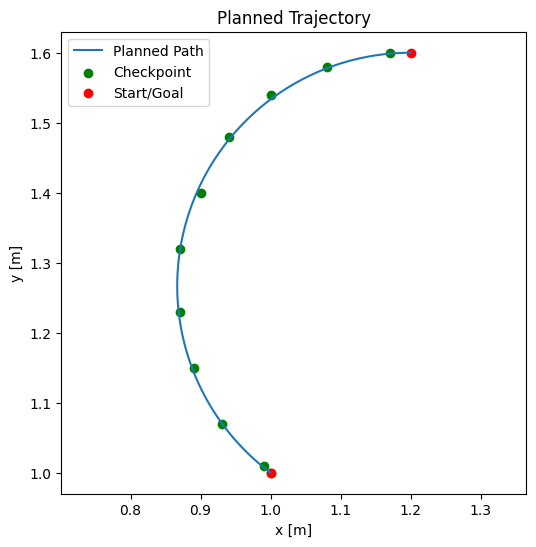

In [9]:
start = FriendlyPose(x=1.2, y=1.6, theta_deg=0)
goal = FriendlyPose(x=1, y=1, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 6.0
│ velocity_x_m_s: 0.10471975511965975
│ angular_velocity_deg_s: -30.0
180.0
[FriendlyPose(x=1.12, y=1.5, theta_deg=354), FriendlyPose(x=1.17, y=1.49, theta_deg=339), FriendlyPose(x=1.22, y=1.46, theta_deg=324), FriendlyPose(x=1.26, y=1.43, theta_deg=309), FriendlyPose(x=1.28, y=1.38, theta_deg=294), FriendlyPose(x=1.3, y=1.33, theta_deg=279), FriendlyPose(x=1.3, y=1.28, theta_deg=264), FriendlyPose(x=1.29, y=1.23, theta_deg=249), FriendlyPose(x=1.26, y=1.18, theta_deg=234), FriendlyPose(x=1.23, y=1.14, theta_deg=219), FriendlyPose(x=1.18, y=1.12, theta_deg=204), FriendlyPose(x=1.13, y=1.1, theta_deg=189), FriendlyPose(x=1.1, y=1.1, theta_deg=180)]


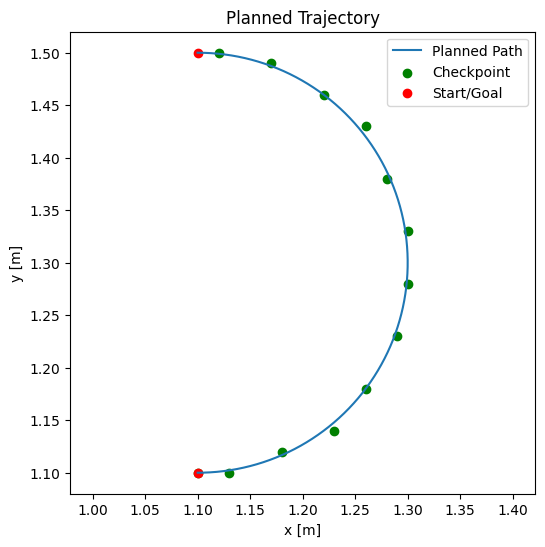

In [10]:
start = FriendlyPose(x=1.1, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1.1, y=1.1, theta_deg=45.0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 6.0
│ velocity_x_m_s: 0.20682151636132806
│ angular_velocity_deg_s: 30.0
180.0
[FriendlyPose(x=1.54, y=1.5, theta_deg=6), FriendlyPose(x=1.64, y=1.53, theta_deg=21), FriendlyPose(x=1.73, y=1.58, theta_deg=36), FriendlyPose(x=1.81, y=1.65, theta_deg=51), FriendlyPose(x=1.86, y=1.73, theta_deg=66), FriendlyPose(x=1.89, y=1.83, theta_deg=81), FriendlyPose(x=1.89, y=1.94, theta_deg=96), FriendlyPose(x=1.87, y=2.04, theta_deg=111), FriendlyPose(x=1.82, y=2.13, theta_deg=126), FriendlyPose(x=1.75, y=2.2, theta_deg=141), FriendlyPose(x=1.66, y=2.26, theta_deg=156), FriendlyPose(x=1.56, y=2.29, theta_deg=171), FriendlyPose(x=1.5, y=2.29, theta_deg=180)]


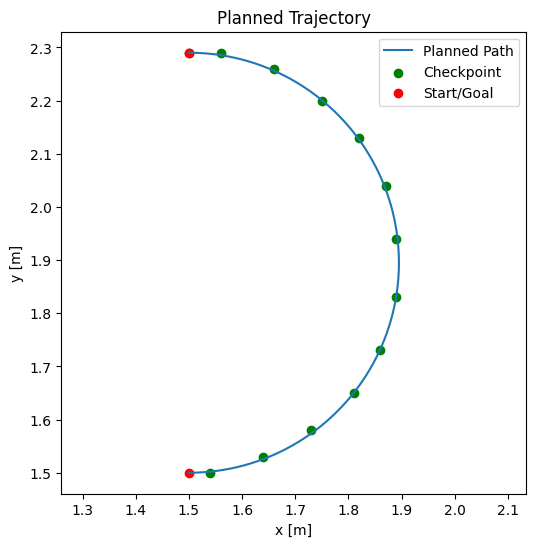

In [11]:
#(150, 150, 0), (150, 229, 180), (150, 165, 0.0)
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
goal = FriendlyPose(x=1.5, y=2.29, theta_deg=180)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 6.0
│ velocity_x_m_s: 0.16755160819145565
│ angular_velocity_deg_s: 30.0
0.0
[FriendlyPose(x=1.47, y=2.29, theta_deg=186), FriendlyPose(x=1.39, y=2.27, theta_deg=201), FriendlyPose(x=1.31, y=2.23, theta_deg=216), FriendlyPose(x=1.25, y=2.17, theta_deg=231), FriendlyPose(x=1.21, y=2.1, theta_deg=246), FriendlyPose(x=1.18, y=2.02, theta_deg=261), FriendlyPose(x=1.18, y=1.94, theta_deg=276), FriendlyPose(x=1.2, y=1.86, theta_deg=291), FriendlyPose(x=1.24, y=1.78, theta_deg=306), FriendlyPose(x=1.3, y=1.72, theta_deg=321), FriendlyPose(x=1.37, y=1.68, theta_deg=336), FriendlyPose(x=1.45, y=1.65, theta_deg=351), FriendlyPose(x=1.5, y=1.65, theta_deg=0)]


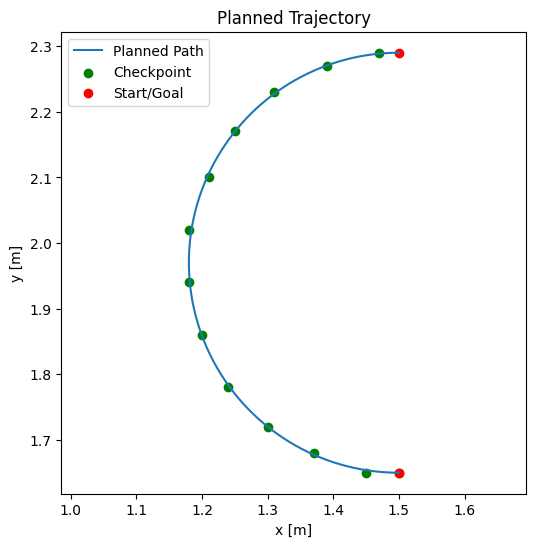

In [12]:
#(150, 150, 0), (150, 229, 180), (150, 165, 0.0)
start = FriendlyPose(x=1.5, y=2.29, theta_deg=180)
goal = FriendlyPose(x=1.5, y=1.65, theta_deg=0)

simulate_and_plot(ps, start, goal)

PlanStep
│ duration: 11.333024885304347
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -8.372301118745584
242.11650307399486
[FriendlyPose(x=2.14, y=4.48, theta_deg=335), FriendlyPose(x=2.32, y=4.39, theta_deg=331), FriendlyPose(x=2.49, y=4.28, theta_deg=327), FriendlyPose(x=2.66, y=4.17, theta_deg=323), FriendlyPose(x=2.81, y=4.04, theta_deg=319), FriendlyPose(x=2.96, y=3.91, theta_deg=314), FriendlyPose(x=3.09, y=3.76, theta_deg=310), FriendlyPose(x=3.21, y=3.6, theta_deg=306), FriendlyPose(x=3.33, y=3.43, theta_deg=302), FriendlyPose(x=3.43, y=3.26, theta_deg=298), FriendlyPose(x=3.51, y=3.08, theta_deg=293), FriendlyPose(x=3.58, y=2.89, theta_deg=289), FriendlyPose(x=3.64, y=2.7, theta_deg=285), FriendlyPose(x=3.69, y=2.51, theta_deg=281), FriendlyPose(x=3.72, y=2.31, theta_deg=277), FriendlyPose(x=3.74, y=2.11, theta_deg=273), FriendlyPose(x=3.74, y=1.91, theta_deg=268), FriendlyPose(x=3.72, y=1.71, theta_deg=264), FriendlyPose(x=3.7, y=1.51, theta_deg=260), FriendlyPose(x=3.65, 

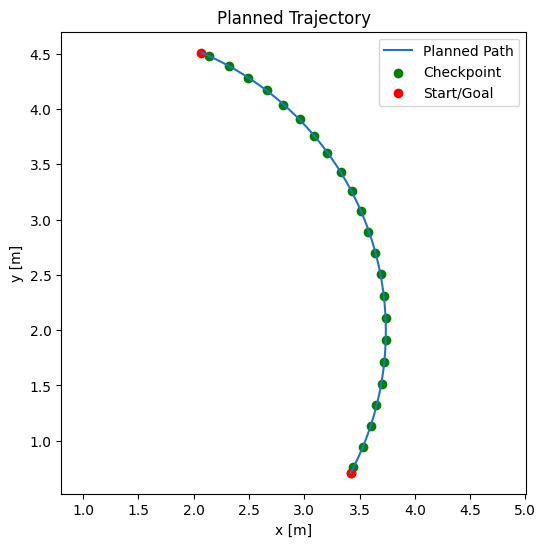

In [13]:
#(207, 451, 337), (342, 71, 242.11650307399486)
start = FriendlyPose(x=2.07, y=4.51, theta_deg=337)
goal = FriendlyPose(x=3.42, y=0.71, theta_deg=242)

simulate_and_plot(ps, start, goal)

In [14]:
start = FriendlyPose(x=1.5, y=1.5, theta_deg=0)
solution = []
window = (3.0 - 0.0) / 6
for i in np.arange(-window, window, 0.05):
    for j in np.arange(-window, window, 0.05):
        if abs(i) < 1e-12 and abs(j) < 1e-12:
            continue
        goal = FriendlyPose(x=1.5 + i, y=1.5 + j, theta_deg=0.0)
        plan, new_heading = connect_poses_with_curvature(ps, start, goal)
        if round(new_heading) % 20 == 0:
            print(f"coordinates: {i}, {j}, heading: {new_heading}")
            solution.append((i, j))

print(len(solution))

coordinates: -0.5, -1.1102230246251565e-16, heading: 0
coordinates: -0.45, -1.1102230246251565e-16, heading: 0
coordinates: -0.4, -1.1102230246251565e-16, heading: 0
coordinates: -0.35000000000000003, -1.1102230246251565e-16, heading: 0
coordinates: -0.30000000000000004, -0.25000000000000006, heading: 79.61114218453042
coordinates: -0.30000000000000004, -1.1102230246251565e-16, heading: 0
coordinates: -0.30000000000000004, 0.24999999999999978, heading: 280.3888578154697
coordinates: -0.25000000000000006, -0.30000000000000004, heading: 100.38885781546958
coordinates: -0.25000000000000006, -1.1102230246251565e-16, heading: 0
coordinates: -0.25000000000000006, 0.2999999999999998, heading: 259.6111421845304
coordinates: -0.20000000000000007, -1.1102230246251565e-16, heading: 0
coordinates: -0.15000000000000008, -1.1102230246251565e-16, heading: 0
coordinates: -0.10000000000000009, -1.1102230246251565e-16, heading: 0
coordinates: -0.0500000000000001, -1.1102230246251565e-16, heading: 0
coor